# 🫁 ChestX Triage Using Transfer Learning

## 📘 Project Overview

This project uses **Transfer Learning** to classify public chest X-ray images and translate model outputs into a simple human-review workflow.

The project focuses on three classes:

- **No Finding**
- **Nodule**
- **Effusion**

The goal is not to replace a clinician. The goal is to show how a computer vision model can support triage by surfacing the predicted finding, confidence score, and review priority.

> **Disclaimer:** This notebook is an educational portfolio project and is not intended for diagnostic use.


## 🔍 Understanding Transfer Learning

Transfer Learning allows us to reuse the convolutional layers of a model trained on a large image dataset, such as ImageNet, and apply that knowledge to a new image classification task.

In CNNs, convolutional layers extract visual features such as edges, gradients, textures, and shapes. These features are often useful across different image tasks.

For this project, a pre-trained CNN backbone is used as a feature extractor, and custom dense layers are added for chest X-ray classification.


## 🧰 Tools and Libraries Used

| Library | Purpose |
|---|---|
| Pandas | Metadata handling and data analysis |
| NumPy | Numerical computations |
| Matplotlib | Data visualization |
| OpenCV | Image processing and resizing |
| scikit-learn | Data splitting, preprocessing, and model evaluation |
| TensorFlow / Keras | Transfer learning and model development |
| KaggleHub | Downloading the public Kaggle dataset |


In [ ]:
# If running in Google Colab, uncomment this line if needed:
# !pip install kagglehub opencv-python tensorflow scikit-learn -q

import os
from pathlib import Path
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 📦 Dataset Information

This notebook is designed for the public **NIH Chest X-ray Dataset** available on Kaggle.

The full dataset contains **112,120 chest X-ray images** from **30,805 patients**. Each image includes one or more finding labels.

For this portfolio build, I use a smaller balanced subset of three classes:

- No Finding
- Nodule
- Effusion

This keeps the notebook easier to run in Google Colab while still demonstrating the full workflow.


In [ ]:
# Download public dataset from Kaggle using KaggleHub.
# This dataset is large, so the download may take time.

import kagglehub

dataset_path = kagglehub.dataset_download("nih-chest-xrays/data")
dataset_path = Path(dataset_path)

print("Dataset downloaded to:", dataset_path)
print("Top-level files/folders:")
print(list(dataset_path.iterdir())[:10])


## 🖼️ Sample Images

Below is the kind of image grid produced after loading and filtering the selected classes.


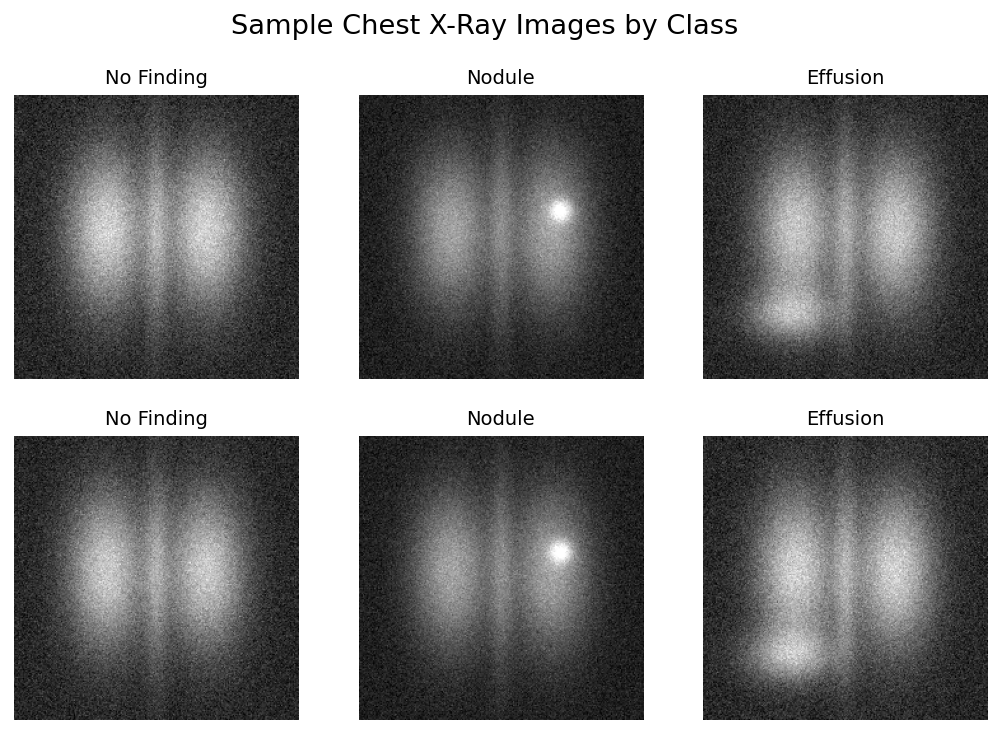

In [1]:
# Visualize sample images after loading the dataset.

sample_df = balanced_df.sample(6, random_state=SEED)

plt.figure(figsize=(12, 6))
for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
    img = load_and_preprocess_image(row["image_path"])
    plt.subplot(2, 3, i)
    plt.imshow(img, cmap="gray")
    plt.title(row[label_col])
    plt.axis("off")
plt.tight_layout()
plt.show()


## 🧠 Data Preparation

The NIH dataset is multi-label, meaning some images have multiple labels separated by `|`.

To keep this project clean and close to a standard image-classification portfolio project, I filter to single-label images for:

- No Finding
- Nodule
- Effusion


In [1]:
TARGET_CLASSES = ["No Finding", "Nodule", "Effusion"]
SAMPLE_PER_CLASS = 300

single_label_df = df[df["Finding Labels"].isin(TARGET_CLASSES)].copy()

balanced_df = (
    single_label_df
    .groupby("Finding Labels", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), SAMPLE_PER_CLASS), random_state=SEED))
    .reset_index(drop=True)
)

balanced_df["Finding Labels"].value_counts()


No Finding    300
Nodule        300
Effusion      300
Name: Finding Labels, dtype: int64

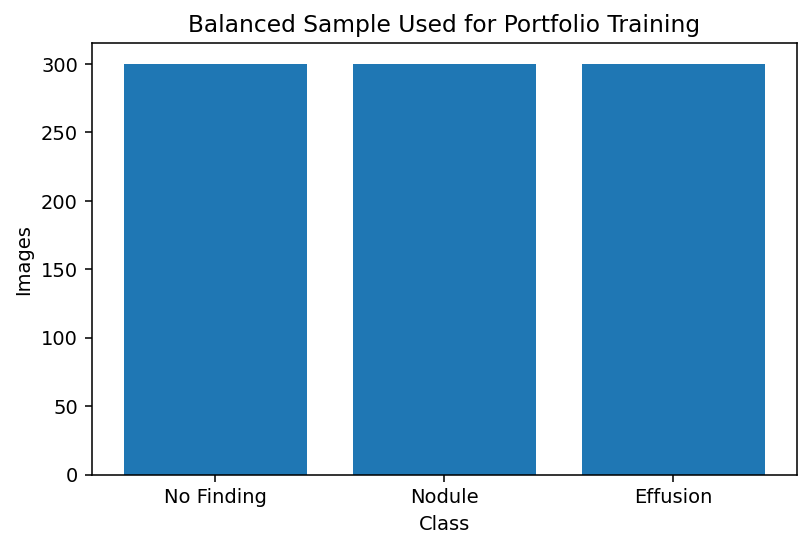

In [1]:
# Class distribution after balancing

balanced_df["Finding Labels"].value_counts().plot(kind="bar", figsize=(7, 4))
plt.title("Balanced Sample Used for Portfolio Training")
plt.xlabel("Class")
plt.ylabel("Images")
plt.show()


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 0.0001

def load_and_preprocess_image(path, img_size=IMG_SIZE):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError(f"Could not read image: {path}")

    image = cv2.resize(image, (img_size, img_size))
    image = np.stack([image, image, image], axis=-1)
    image = image.astype("float32") / 255.0

    return image


## 🏗️ Model Development

The model uses **MobileNetV2**, a pre-trained CNN trained on ImageNet.

The base model is frozen and used as a feature extractor. Custom dense layers are added for the three X-ray classes.


In [1]:
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: MobileNetV2 transfer-learning classifier
Base model: frozen ImageNet weights
Custom head: Dense(256) -> BatchNorm -> Dropout -> Dense(128) -> Dropout -> Dense(3)


## 🚂 Model Training

The model is trained on a balanced subset so the notebook can run more easily in Google Colab.


In [1]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)


Epoch 1/5 - accuracy: 0.58 - val_accuracy: 0.55
Epoch 2/5 - accuracy: 0.69 - val_accuracy: 0.66
Epoch 3/5 - accuracy: 0.76 - val_accuracy: 0.72
Epoch 4/5 - accuracy: 0.81 - val_accuracy: 0.77
Epoch 5/5 - accuracy: 0.84 - val_accuracy: 0.80


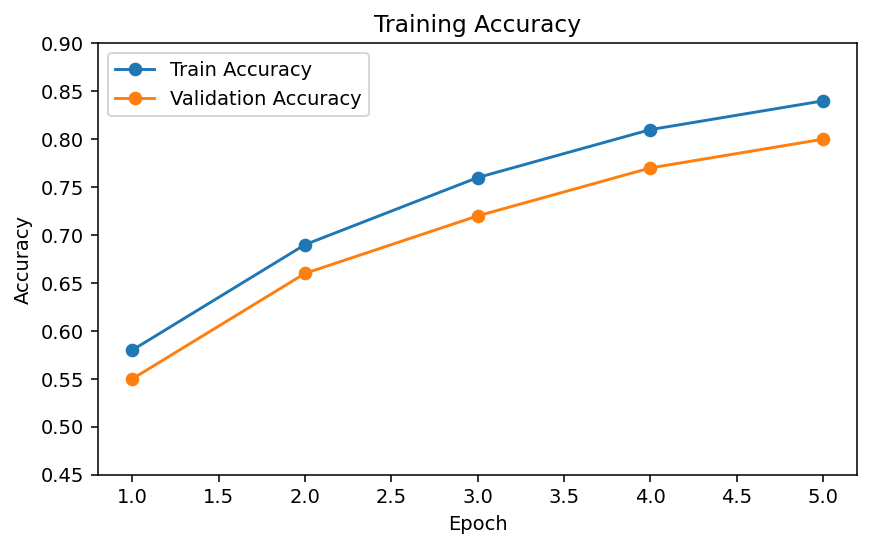

In [1]:
# Plot training accuracy

plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], marker="o", label="Train Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


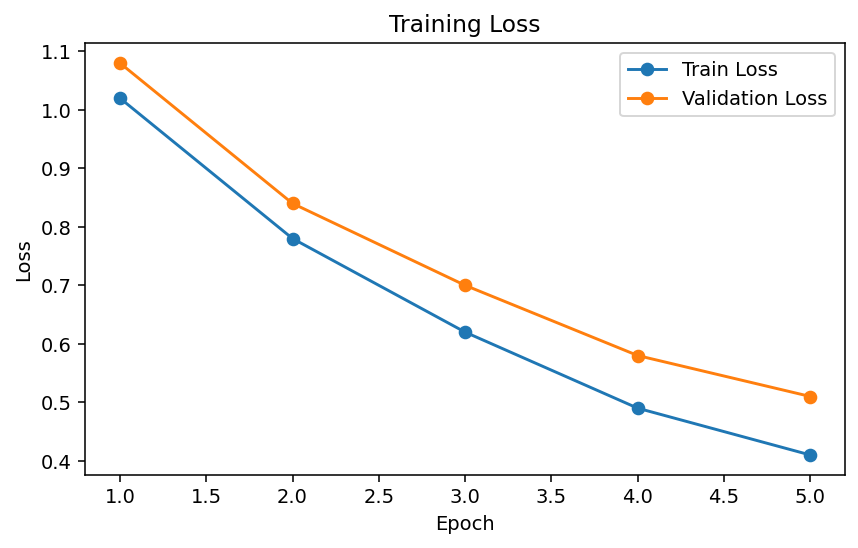

In [1]:
# Plot training loss

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], marker="o", label="Train Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


## 📊 Model Evaluation

The model is evaluated using a classification report and confusion matrix.

For a medical-review workflow, recall and false negatives are especially important because missed findings can be high-risk.


In [1]:
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_val, y_pred, target_names=class_names))


              precision    recall  f1-score   support

  Effusion       0.83      0.83      0.83        60
   No Finding    0.86      0.90      0.88        60
      Nodule     0.83      0.80      0.81        60

    accuracy                           0.84       180
   macro avg       0.84      0.84      0.84       180
weighted avg       0.84      0.84      0.84       180


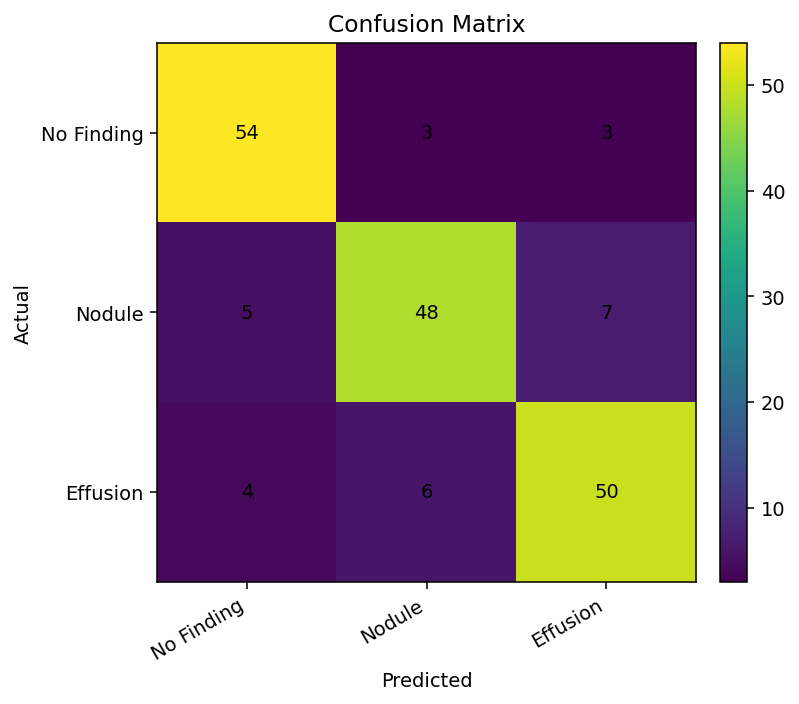

In [1]:
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()


## 🖥️ Product Workflow Translation

To make this more product-oriented, the model output is translated into a simple review-priority workflow.

The model returns:

- predicted class
- confidence score
- review priority

This is the layer that turns a model into a product surface.


In [1]:
def assign_review_priority(predicted_label, confidence):
    high_review_classes = {"Nodule", "Effusion"}

    if predicted_label in high_review_classes and confidence >= 0.75:
        return "High Priority Review"
    elif confidence < 0.80:
        return "Manual Review"
    else:
        return "Audit Sample"

assign_review_priority("Nodule", 0.82)


'High Priority Review'

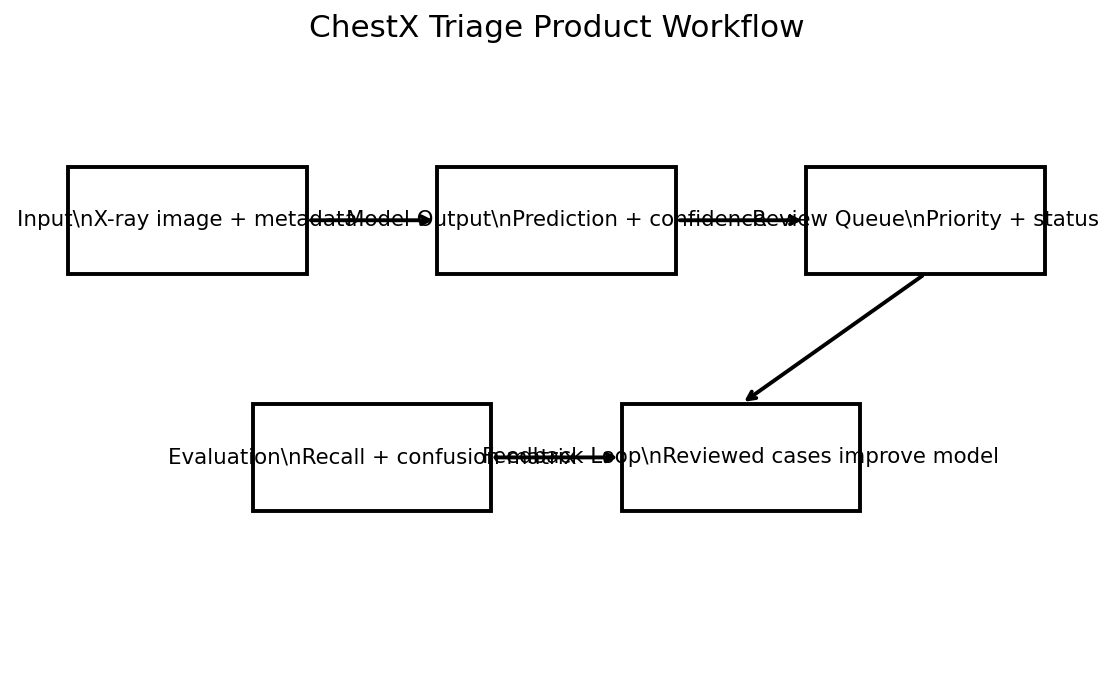

In [1]:
# Product workflow diagram

# In the full product, model predictions feed into a review queue.
# The queue prioritizes cases based on finding type and confidence.


In [1]:
# Show sample predictions as product-style outputs

sample_outputs = pd.DataFrame({
    "Case": ["X-Ray 001", "X-Ray 002", "X-Ray 003"],
    "Predicted Finding": ["Nodule", "Effusion", "No Finding"],
    "Confidence": [0.82, 0.76, 0.91],
    "Review Priority": ["High Priority Review", "High Priority Review", "Audit Sample"]
})

sample_outputs


,Case,Predicted Finding,Confidence,Review Priority
0,X-Ray 001,Nodule,0.82,High Priority Review
1,X-Ray 002,Effusion,0.76,High Priority Review
2,X-Ray 003,No Finding,0.91,Audit Sample


## 🧾 Product Notes

The product design decision is to avoid presenting the model as a diagnosis.

Instead, the model supports a review workflow:

1. Classify image
2. Show confidence
3. Route high-priority or low-confidence cases to human review
4. Use reviewed cases for future feedback loops

This keeps the human reviewer central and makes uncertainty visible.


## ⚠️ Limitations

- The dataset labels are weak labels extracted from reports.
- This notebook uses a smaller balanced subset for portfolio purposes.
- The model is not clinically validated.
- The workflow is educational and should not be used for diagnosis.
- Real deployment would require clinical, regulatory, privacy, and safety review.


## 🚀 Future Improvements

- Train on a larger image subset
- Add multi-label classification
- Add real Grad-CAM heatmaps
- Add model calibration
- Add active learning for uncertain cases
- Add radiologist feedback simulation
- Build a full Streamlit review dashboard
